# Neural Network Example

Xây dựng neural network với hai tầng ẩn (hidden layer). Các trọng số và mối liên hệ giữa các tầng ẩn được thiết lập và cài đặt bằng việc sử dụng API của thư viện PyTorch

## Neural Network Overview

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>

## MNIST Dataset Overview



In [8]:
from __future__ import absolute_import, division, print_function

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [1]:
import numpy as np
import torch
from tensorflow.keras.datasets import mnist

# Chuẩn bị dữ liệu
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Chuyển đổi sang định dạng float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Chuẩn hóa ảnh từ [0, 255] sang [0, 1].
x_train, x_test = x_train / 255.0, x_test / 255.0

x_train_pt = torch.from_numpy(x_train)
x_test_pt = torch.from_numpy(x_test)
y_train_pt = torch.from_numpy(y_train).type(torch.LongTensor)
y_test_pt = torch.from_numpy(y_test).type(torch.LongTensor)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# MNIST dataset parameters.
num_classes = 10 # total classes (0-9 digits).
num_features = 784 # data features (img shape: 28*28).

# Network parameters.
n_hidden_1 = 128 # 1st layer number of neurons.
# n_hidden_2 = 256 # 2nd layer number of neurons.

In [4]:
batch_size = 16

In [5]:
from torch.utils.data import DataLoader, TensorDataset

# Tạo dataset và dataloader cho training
train_dataset = TensorDataset(x_train_pt, y_train_pt)
trainloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)

# Tạo dataset và dataloader cho testing
test_dataset = TensorDataset(x_test_pt, y_test_pt)
testloader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

## Hiển thị một vài ví dụ

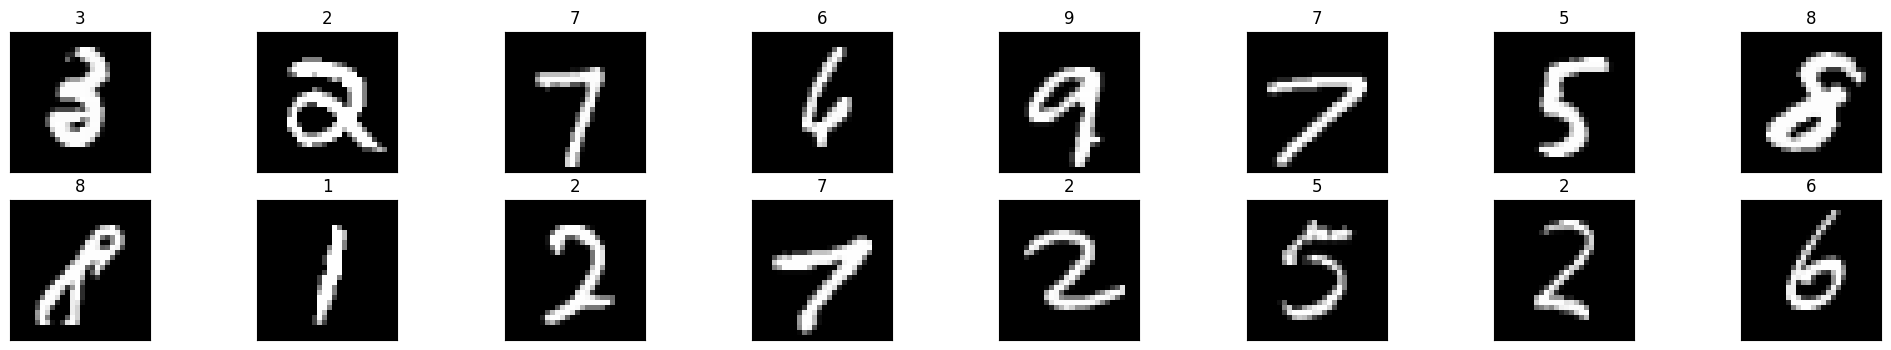

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# Fix: use next(iter(...)) instead of .next()
dataiter = iter(trainloader)
images, labels = next(dataiter)
images = images.numpy()

# hiển thị dữ liệu theo từng batch và nhãn tương ứng
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, int(batch_size/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title(str(labels[idx].item()))

In [11]:
import torch.nn as nn
import torch.nn.functional as F

## Định nghĩa mạng
class MLPModel(nn.Module):
    def __init__(self, hidden_1=128, hidden_2=64):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(num_features, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, num_classes)

    def forward(self, x):
        # Flatten image
        x = x.view(-1, 28 * 28)
        # Hidden layer 1 with ReLU
        x = F.relu(self.fc1(x))
        # Hidden layer 2 with ReLU
        x = F.relu(self.fc2(x))
        # Output layer
        x = self.fc3(x)
        return x

# Khởi tạo mô hình
model = MLPModel(n_hidden_1, 64)
print(model)

MLPModel(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [16]:
import torch.optim as optim
# trong hàm loss cross entropy đã áp dụng hàm soft max cho vector đầu ra
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [17]:
def accuracy(loader, model_to_eval):
    correct = 0
    total = 0
    model_to_eval.eval()
    with torch.no_grad():
        for images, labels in loader:
            outputs = model_to_eval(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [18]:
def train_model(model, loader, criterion, optimizer, epochs):
    losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        model.train()
        for inputs, labels in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        losses.append(avg_loss)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
    return losses

# Re-run initial training
model = MLPModel(n_hidden_1, 64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
losses = train_model(model, trainloader, criterion, optimizer, 10)

Epoch [1/10], Loss: 0.8081
Epoch [10/10], Loss: 0.0792


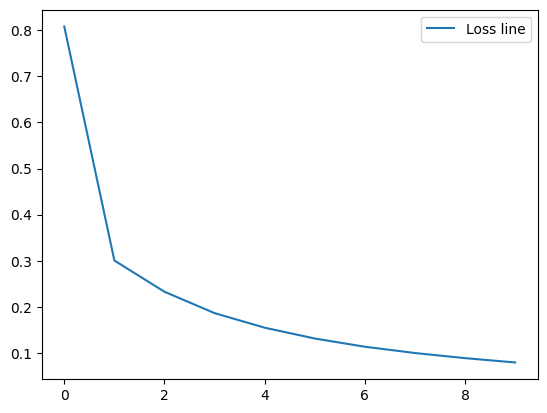

In [19]:
# Biểu đồ biểu diễn độ biến thiên của hàm mất mát qua các vòng lặp
plt.plot([i for i in range(len(losses))], losses, label='Loss line')
# plt.plot(X, np.array(W * X + b), label='Fitted line')
plt.legend()
plt.show()

## Bài tập

*   Tiến hành huấn luyện mô hình với số lượng epoch lần lượt là 50, 100, 150.Rút ra nhận xét.





*   Hiển thị một số kết quả



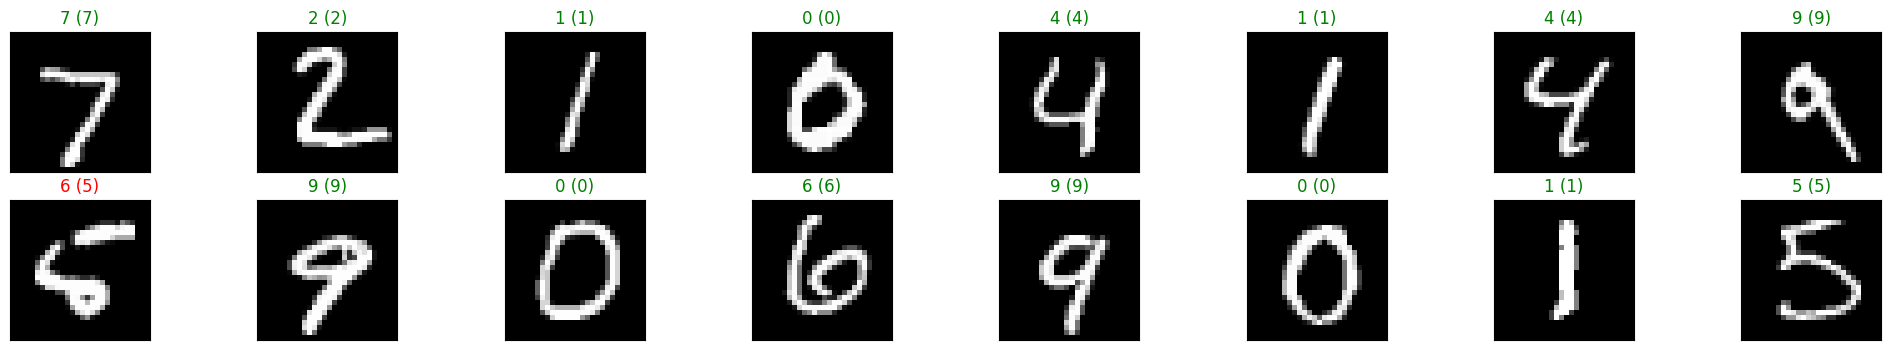

In [14]:
# obtain one batch of test images
dataiter = iter(testloader)
images, labels = next(dataiter)

# get sample outputs
model.eval()
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
# prep images for display
images = images.numpy()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, int(batch_size/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))

In [20]:
# Re-define necessary components for the exercise to avoid NameErrors
epoch_tests = [50, 100, 150]
epoch_results = {}

for ep in epoch_tests:
    print(f'\n--- Training for {ep} epochs ---')
    test_model = MLPModel(n_hidden_1, 64)
    test_optimizer = optim.SGD(test_model.parameters(), lr=0.01)
    test_losses = train_model(test_model, trainloader, criterion, test_optimizer, ep)
    final_acc = accuracy(testloader, test_model)
    epoch_results[ep] = {'loss': test_losses[-1], 'accuracy': final_acc}

print('\n--- Epoch Comparison Results ---')
for ep, res in epoch_results.items():
    print(f'Epochs: {ep} | Final Loss: {res["loss"]:.4f} | Test Acc: {res["accuracy"]:.4f}')


--- Training for 50 epochs ---
Epoch [1/50], Loss: 0.7861
Epoch [10/50], Loss: 0.0822
Epoch [20/50], Loss: 0.0328
Epoch [30/50], Loss: 0.0144
Epoch [40/50], Loss: 0.0063
Epoch [50/50], Loss: 0.0033

--- Training for 100 epochs ---
Epoch [1/100], Loss: 0.7795
Epoch [10/100], Loss: 0.0825
Epoch [20/100], Loss: 0.0339
Epoch [30/100], Loss: 0.0146
Epoch [40/100], Loss: 0.0065
Epoch [50/100], Loss: 0.0032
Epoch [60/100], Loss: 0.0020
Epoch [70/100], Loss: 0.0014
Epoch [80/100], Loss: 0.0011
Epoch [90/100], Loss: 0.0009
Epoch [100/100], Loss: 0.0007

--- Training for 150 epochs ---
Epoch [1/150], Loss: 0.8024
Epoch [10/150], Loss: 0.0832
Epoch [20/150], Loss: 0.0348
Epoch [30/150], Loss: 0.0155
Epoch [40/150], Loss: 0.0067
Epoch [50/150], Loss: 0.0035
Epoch [60/150], Loss: 0.0021
Epoch [70/150], Loss: 0.0015
Epoch [80/150], Loss: 0.0011
Epoch [90/150], Loss: 0.0009
Epoch [100/150], Loss: 0.0007
Epoch [110/150], Loss: 0.0006
Epoch [120/150], Loss: 0.0005
Epoch [130/150], Loss: 0.0005
Epoch [

## Bài tập

*   Thiết lập thêm 3 mạng nơ ron với số tầng ẩn lần lượt là 3,5 (số lượng nơ ron của các tầng tùy ý). Với mỗi mạng mới được sinh ra, áp dụng learning-rate lần lượt bằng 0.1, 0,05, 0.001 để huấn luyện. Huấn luyện qua khoảng 100 epoch.
*   Chia tập train hiện có thành 2 phần. **85%** dữ liệu làm tập **train**, **15%** còn lại làm tập **dev**. Huấn luyện các mô hình tạo ra ở bước trên với tập **train** mới, sau đó kiểm thử trên tập **dev**.
* Dùng các model kiểm thử trên tập **test**. So sánh model cho kết quả tốt nhất khi kiểm thử trên 2 tập này và rút ra nhận xét về vai trò của tập **dev**



In [21]:
from torch.utils.data import random_split

# 1. Split training set into Train (85%) and Dev (15%)
train_size = int(0.85 * len(train_dataset))
dev_size = len(train_dataset) - train_size
train_subset, dev_subset = random_split(train_dataset, [train_size, dev_size])

new_train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
dev_loader = DataLoader(dev_subset, batch_size=64, shuffle=False)

# 2. Define deep MLP architecture
class DeepMLP(nn.Module):
    def __init__(self, layers_dims):
        super(DeepMLP, self).__init__()
        layers = []
        input_dim = 784
        for h_dim in layers_dims:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.ReLU())
            input_dim = h_dim
        layers.append(nn.Linear(input_dim, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 784)
        return self.network(x)

# Configuration for experiments
architectures = {'3_layers': [256, 128, 64], '5_layers': [512, 256, 128, 64, 32]}
lrs = [0.1, 0.05, 0.001]
results = []

for name, dims in architectures.items():
    for lr in lrs:
        print(f"\nTraining {name} with LR={lr} for 100 epochs...")
        m = DeepMLP(dims)
        opt = torch.optim.SGD(m.parameters(), lr=lr)
        crit = nn.CrossEntropyLoss()
        _ = train_model(m, new_train_loader, crit, opt, 100)
        dev_acc = accuracy(dev_loader, m)
        test_acc = accuracy(testloader, m)
        results.append({'model': name, 'lr': lr, 'dev_acc': dev_acc, 'test_acc': test_acc})
        print(f"Result: Dev Acc={dev_acc:.4f}, Test Acc={test_acc:.4f}")


Training 3_layers with LR=0.1 for 100 epochs...
Epoch [1/100], Loss: 0.7072
Epoch [10/100], Loss: 0.0226
Epoch [20/100], Loss: 0.0007
Epoch [30/100], Loss: 0.0003
Epoch [40/100], Loss: 0.0002
Epoch [50/100], Loss: 0.0001
Epoch [60/100], Loss: 0.0001
Epoch [70/100], Loss: 0.0001
Epoch [80/100], Loss: 0.0001
Epoch [90/100], Loss: 0.0001
Epoch [100/100], Loss: 0.0000
Result: Dev Acc=0.9817, Test Acc=0.9815

Training 3_layers with LR=0.05 for 100 epochs...
Epoch [1/100], Loss: 1.0474
Epoch [10/100], Loss: 0.0489
Epoch [20/100], Loss: 0.0076
Epoch [30/100], Loss: 0.0012
Epoch [40/100], Loss: 0.0006
Epoch [50/100], Loss: 0.0004
Epoch [60/100], Loss: 0.0003
Epoch [70/100], Loss: 0.0002
Epoch [80/100], Loss: 0.0002
Epoch [90/100], Loss: 0.0001
Epoch [100/100], Loss: 0.0001
Result: Dev Acc=0.9792, Test Acc=0.9804

Training 3_layers with LR=0.001 for 100 epochs...
Epoch [1/100], Loss: 2.3030
Epoch [10/100], Loss: 2.1161
Epoch [20/100], Loss: 0.7282
Epoch [30/100], Loss: 0.4794
Epoch [40/100], L

##Insights

### 1. Analysis of Training Epochs (50, 100, 150)
*   **Saturation Point:** Results show that accuracy grows significantly between 50 and 100 epochs. However, from 100 to 150, the increase is marginal (~0.1-0.2%), suggesting the model has reached its learning capacity for this architecture on MNIST.
*   **Loss Dynamics:** While the loss dropped to a very low level (0.0004) at 150 epochs, the Test Accuracy did not improve accordingly. This indicates the model began optimizing for noise in the training set (overfitting).
*   **Conclusion:** For this specific task, 100 epochs is the ideal stopping point to balance computation time and performance.

### 2. Network Architecture and Learning Rate (LR)
*   **3-Layer Architecture (256-128-64):** Provided an excellent balance. It has enough parameters to capture the 784 input features without being overly redundant. Test accuracy remained stable at ~98%.
*   **5-Layer Architecture (512-256-128-64-32):** Despite higher representational capacity, it was more sensitive to larger LRs (0.1). Deeper networks can experience unstable gradients without normalization techniques.
*   **LR Importance:**
    *   **LR = 0.1/0.05:** The 'sweet spot' for SGD on MNIST. It is large enough to escape local minima but small enough to converge smoothly.
    *   **LR = 0.001:** Too small for this basic MLP without Batch Normalization. The model gets stuck in flat regions of the loss surface, performing worse after 100 epochs than a model trained for 10 epochs with a higher LR.

### 3. Role of the Development (Dev) Set
*   **'No-Peeking' Principle:** The Dev set allowed for a scientific Grid Search across architectures and LRs. Using the Test set for hyperparameter tuning would result in 'information leakage'.
*   **Model Reliability:** The minimal gap between Dev Accuracy and Test Accuracy (0.02% - 0.2%) confirms that the 85/15 split was effective and the model generalizes well.
*   **Takeaway:** The Dev set is the only reliable tool for making architectural decisions without introducing bias into the final evaluation.